# The Main Notebook for Evaluating the RSi Model

In [3]:
import argparse
import os
import random
import shutil
import time
import warnings
from enum import Enum
import pandas as pd

import argparse
import torch
import torch.nn.parallel
import torch.distributed as dist
import torch.optim
import torch.multiprocessing as mp
import torch.utils.data
import torch.utils.data.distributed

from prettytable import PrettyTable

from src.model.compound import ECFPCompoundModel, ChemBERTaCompoundModel, DrugEmbeddingCompoundModel
from src.model.model.drug_response_model import DrugResponseModel
from transformers import AutoModelForSequenceClassification, AutoTokenizer, pipeline, RobertaModel, RobertaTokenizer

from src.utils.data import CompoundEncoder
from src.utils.tree import MutTreeParser
from src.utils.data.dataset import DrugResponseDataset, DrugResponseCollator, DrugResponseSampler, DrugBatchSampler, DrugDataset, CellLineBatchSampler
from src.utils.trainer import DrugResponseTrainer, DrugTrainer, DrugResponseFineTuner
import numpy as np
import torch.nn as nn
import pickle
import pubchempy as pcp
import statistics as s
from torch.utils.data.dataloader import DataLoader
import matplotlib.pyplot as plt
import pandas as pd
import math
from operator import itemgetter
from scipy.stats import ttest_ind

import gc
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import  StepLR
from torch.nn.utils import prune
from sklearn import metrics
from scipy.stats import spearmanr, pearsonr
from tqdm import tqdm
import numpy as np
import copy
from transformers import get_linear_schedule_with_warmup
from src.utils.trainer import CCCLoss
from src.utils.data import move_to
import copy
from torch.nn import functional as F
import pickle

In [4]:
import os, sys

class HiddenPrints:
    def __enter__(self):
        self._original_stdout = sys.stdout
        sys.stdout = open(os.devnull, 'w')

    def __exit__(self, exc_type, exc_val, exc_tb):
        sys.stdout.close()
        sys.stdout = self._original_stdout

## Function for Instantiating the Model

In [5]:
def instantiate_model(train_dataset, saved_model, diff_transformer=True, new_copynumber = True):

    train_dataset = pd.read_csv(train_dataset, header=None, sep='\t')
    onto = "data/ontology_ctg_av.txt"
    gene2id = "data/gene2ind_ctg_av.txt"
    if new_copynumber:
        genotypes = {'mutation': 'data/cell2mutation_ctg_av.txt', 'cna': 'data/cell2cnamplification2_ctg_av.txt', 'cnd': 'data/cell2cndeletion2_ctg_av.txt'}
    else:
        genotypes = {'mutation': 'data/cell2mutation_ctg_av.txt', 'cna': 'data/old_copynumber/cell2cnamplification_ctg_av.txt', 'cnd': 'data/old_copynumber/cell2cndeletion_ctg_av.txt'}
    hidden_dims = 128
    dropout = 0.2
    batch_size = 32
    jobs = 16
    lr = 0.0001
    wd = 0.01


    with HiddenPrints():
        compound_encoder = CompoundEncoder('Embedding', dataset=train_dataset, out="dummy/")
        compound_model = DrugEmbeddingCompoundModel(compound_encoder.num_drugs(), hidden_dims)

        tree_parser = MutTreeParser(onto, gene2id)

        device = "cuda" if torch.cuda.is_available() else "cpu"

        drug_response_model = DrugResponseModel(tree_parser, list(genotypes.keys()), hidden_dims, compound_model, 
                                                dropout=dropout, diff_transformer=diff_transformer)
    
        model = torch.load(saved_model, map_location=torch.device(device))
        model = model["state_dict"]

        drug_response_model.load_state_dict(model)
        drug_response_model.to(device)

        return(drug_response_model)

## Evaluation Functions (Pearson or Odds Ratio)

In [6]:
def evaluate_model(train_dataset, test_dataset, model, sys2cell, cell2sys, sys2gene, gene2drug, mut2gene, with_indices, method="pearson", new_copynumber = True):
    
    train_dataset = pd.read_csv(train_dataset, header=None, sep='\t')
    test_dataset = pd.read_csv(test_dataset, header=None, sep='\t')
    onto = "data/ontology_ctg_av.txt"
    gene2id = "data/gene2ind_ctg_av.txt"
    cell2id = "data/cell2ind_av.txt"
    if new_copynumber:
        genotypes = {'mutation': 'data/cell2mutation_ctg_av.txt', 'cna': 'data/cell2cnamplification2_ctg_av.txt', 'cnd': 'data/cell2cndeletion2_ctg_av.txt'}
    else:
        genotypes = {'mutation': 'data/cell2mutation_ctg_av.txt', 'cna': 'data/old_copynumber/cell2cnamplification_ctg_av.txt', 'cnd': 'data/old_copynumber/cell2cndeletion_ctg_av.txt'}
    jobs = 16
    batch_size = 32

    device = "cuda" if torch.cuda.is_available() else "cpu"

    with HiddenPrints():
        compound_encoder = CompoundEncoder('Embedding', dataset=train_dataset, out="dummy/") # Keep this same as train dataset
        tree_parser = MutTreeParser(onto, gene2id)
    
        test_drug_response_dataset = DrugResponseDataset(test_dataset, cell2id, genotypes, compound_encoder, tree_parser, 
                                                         mut2gene=mut2gene, with_indices=with_indices)
        drug_response_collator = DrugResponseCollator(tree_parser, list(genotypes.keys()), compound_encoder, 
                                                      mut2gene=mut2gene, with_indices=with_indices)
        test_drug_response_dataloader = DataLoader(test_drug_response_dataset, shuffle=False, batch_size=batch_size,
                                                   num_workers=jobs, collate_fn=drug_response_collator)
        torch.cuda.empty_cache()

        if method == "pearson":
            performance = evaluate(model, test_drug_response_dataloader, device, sys2cell, cell2sys, sys2gene, 
                                   gene2drug, mut2gene, with_indices, "pearson")
        elif method == "odds ratio":
            performance = evaluate(model, test_drug_response_dataloader, device, sys2cell, cell2sys, sys2gene, 
                                   gene2drug, mut2gene, with_indices, "odds ratio")
            
        return performance

### Main Evaluation Helper Function

In [7]:
def evaluate(model, dataloader, device, sys2cell, cell2sys, sys2gene, gene2drug, mut2gene, with_indices, method):
    
    trues = []
    results = []
    performance = {}

    test_df = dataloader.dataset.drug_response_df.reset_index()
    test_grouped = test_df.reset_index().groupby(1)
    nested_subtrees_forward = move_to(dataloader.dataset.tree_parser.get_nested_subtree_mask(['default'], direction='forward'), device)
    nested_subtrees_backward = move_to(dataloader.dataset.tree_parser.get_nested_subtree_mask(['default'], direction='backward'), device)
    gene2system_mask = move_to(torch.tensor(dataloader.dataset.tree_parser.gene2sys_mask, dtype=torch.bool), device)
    system2gene_mask = move_to(torch.tensor(dataloader.dataset.tree_parser.sys2gene_mask, dtype=torch.bool), device)
    
    model.to(device)
    model.eval()
    with torch.no_grad():
        for i, batch in enumerate(dataloader):
            trues.append(batch['response_mean'] + batch['response_residual'])
            batch = move_to(batch, device)
            drug_response_predicted = model(batch['genotype'], batch['drug'],
                                            nested_subtrees_forward, nested_subtrees_backward,
                                            gene2system_mask,
                                            system2gene_mask,
                                            sys2cell=sys2cell, 
                                            cell2sys=cell2sys, 
                                            sys2gene=sys2gene, 
                                            gene2drug=gene2drug, 
                                            mut2gene=mut2gene, 
                                            with_indices=with_indices)
            drug_response_predicted_detached = drug_response_predicted.detach().cpu().numpy()
            results.append(drug_response_predicted_detached)
            del drug_response_predicted
            del drug_response_predicted_detached
            del batch
            
    results = np.concatenate(results)[:, 0]
    
    for smiles, indice in test_grouped.groups.items():
        drug = smiles_to_name[smiles]
        if len(indice) <= 1:
            continue
        if method == "pearson":
            pearson = pearsonr(test_df.loc[indice][2], results[indice])[0]
            performance[drug] = pearson
        elif method == "odds ratio":
            true, predicted = np.asarray(test_df.loc[indice][2]), np.asarray(results[indice])
            odds = odds_ratio(true, predicted)
            performance[drug] = odds

    return performance

### Odds Ratio Helper Functions

In [8]:
def odds_ratio(test, predict):
    
    cell_drug_auc_true = dict(zip(list(range(0, len(test), 1)), test))
    cell_drug_auc_pred = dict(zip(list(range(0, len(predict), 1)), predict))
    cell_drug_auc_true = {k: v for k, v in cell_drug_auc_true.items() if not math.isnan(v)}
    cell_drug_auc_pred = {k: v for k, v in cell_drug_auc_pred.items() if cell_drug_auc_true.get(k)}
    
    top_res_true, top_sen_true = top_res_sen(cell_drug_auc_true, 0.25)
    top_res_pred, top_sen_pred = top_res_sen(cell_drug_auc_pred, 0.50)
    
    true_res_pred_res = len(list(set(top_res_true).intersection(set(top_res_pred))))
    true_res_pred_sen = len(list(set(top_res_true).intersection(set(top_sen_pred))))
    true_sen_pred_res = len(list(set(top_sen_true).intersection(set(top_res_pred))))
    true_sen_pred_sen = len(list(set(top_sen_true).intersection(set(top_sen_pred))))

    odds = (true_res_pred_res * true_sen_pred_sen) / (true_res_pred_sen * true_sen_pred_res)

    return(odds)

# Expect a dict of of drug response for a cell-line (cell-line could just be index)
# Top N resistance and sensitive cell-lines
def top_res_sen(cell_drug_auc, percentile):
    
    N = math.floor(percentile*len(cell_drug_auc))
    top_N_res = list(dict(sorted(cell_drug_auc.items(), key=itemgetter(1), reverse=True)[:N]).keys())
    top_N_sen = list(dict(sorted(cell_drug_auc.items(), key=itemgetter(1), reverse=False)[:N]).keys())

    return(top_N_res, top_N_sen)

## RSI Drug Mapping

In [9]:
rsi_drugs = ['Etoposide', 'Camptothecin', 'Gemcitabine', 'Cisplatin', 'CD437', 'Olaparib', 'MK-1775', '5-FU', 'Ceralasertib', 'Bleomycin-a2', 'Doxorubicin', 'Methotrexate']
smiles_to_name = {}
for rsi in rsi_drugs:
    cid = pcp.get_cids(rsi, 'name')[0]
    c = pcp.Compound.from_cid(cid)
    smiles_to_name[c.isomeric_smiles] = rsi
smiles_to_name['N.N.[Cl-].[Cl-].[Pt+2]'] = 'Cisplatin'

## Compare G2PT to Multi-Task

In [10]:
loaded = torch.load('models_rsi/rsi_model_0.pt', map_location=torch.device('cpu'))
print(loaded['arguments'])

Namespace(batch_size=32, bert=None, cell2id='data/cell2ind_av.txt', cell2sys=True, compound_epochs=10, compound_layers=[256], cuda=0, diff_transformer=True, dist_backend='nccl', dist_url='tcp://224.66.41.62:23456', distributed=False, dropout=0.2, drug_embedding=True, epochs=500, gene2drug=False, gene2id='data/gene2ind_ctg_av.txt', gene_embedding=None, genotypes={'mutation': 'data/cell2mutation_ctg_av.txt', 'cna': 'data/old_copynumber/cell2cnamplification_ctg_av.txt', 'cnd': 'data/old_copynumber/cell2cndeletion_ctg_av.txt'}, gpu=0, hidden_dims=128, jobs=16, l2_lambda=0.01, local_rank=1, lr=0.0001, model=None, multiprocessing_distributed=False, mut2gene=True, n_bits=512, onto='data/ontology_ctg_av.txt', out='models_rsi/rsi_model_0.pt', radius=2, rank=-1, seed=None, subtree_order=['default'], sys2cell=True, sys2gene=False, system_embedding=None, test='data/train_splits/test_dataset_rsi_0.txt', train='data/train_splits/train_dataset_rsi_0.txt', val='data/train_splits/val_dataset_rsi_0.txt'

### Instantiate and Evaluate G2PT (Pearson and Odds)

In [11]:
g2pt_pearson = []
g2pt_odds = []
for i in range(5):
    train = 'data/train_splits/train_dataset_rsi_'+str(i)+'.txt'
    test = 'data/train_splits/test_dataset_rsi_'+str(i)+'.txt'
    model = 'models_rsi/rsi_model_'+str(i)+'.pt'
    model_i = instantiate_model(train, model)
    performance_i_pearson = evaluate_model(train, test, model_i, sys2cell=True, cell2sys=True, sys2gene=False, gene2drug=False, 
                                           mut2gene=True, with_indices=True, method="pearson", new_copynumber = False)
    performance_i_odds = evaluate_model(train, test, model_i, sys2cell=True, cell2sys=True, sys2gene=False, gene2drug=False, 
                                        mut2gene=True, with_indices=True, method="odds ratio", new_copynumber = False)
    g2pt_pearson.append(performance_i_pearson)
    g2pt_odds.append(performance_i_odds)

### Evaluate Multi-Task Pearson

In [59]:
multitask_dir = '/cellar/users/zwallace/multitask_vnn'
main_drugs = []
with open(multitask_dir+"/sample/task_list_main.txt", "r") as file:
    for line in file:
        main_drugs.append(line.strip())

extra_drugs = []
with open(multitask_dir+"/sample/task_list_extra.txt", "r") as file:
    for line in file:
        extra_drugs.append(line.strip())

multitask_pearson = {0:{}, 1:{}, 2:{}, 3:{}, 4:{}}
for i in range(5):
    main_performance = []
    with open(multitask_dir+"/model_main_old_"+str(i)+"/test.log", "r") as file:
        for line in file:
            main_performance.append(line.strip())
    main_performance = main_performance[2].split("[")[1].split("]")[0].rstrip().split()
    main_performance = list(np.float_(main_performance))
    for j in range(len(main_drugs)):
        name = smiles_to_name[main_drugs[j]]
        multitask_pearson[i][name] = main_performance[j]

for i in range(5):
    extra_performance = []
    with open(multitask_dir+"/model_extra_old_"+str(i)+"/test.log", "r") as file:
        for line in file:
            extra_performance.append(line.strip())
    extra_performance = extra_performance[2].split("[")[1].split("]")[0].rstrip().split()
    extra_performance = list(np.float_(extra_performance))
    for j in range(len(extra_drugs)):
        name = smiles_to_name[extra_drugs[j]]
        multitask_pearson[i][name] = extra_performance[j]

### Evaluate Mult-Task Odds Ratio

In [60]:
multitask_dir = '/cellar/users/zwallace/multitask_vnn'
main_drugs = []
with open(multitask_dir+"/sample/task_list_main.txt", "r") as file:
    for line in file:
        main_drugs.append(line.strip())

extra_drugs = []
with open(multitask_dir+"/sample/task_list_extra.txt", "r") as file:
    for line in file:
        extra_drugs.append(line.strip())

multitask_odds = {0:{}, 1:{}, 2:{}, 3:{}, 4:{}}
for i in range(5):
    true = pd.read_csv(multitask_dir+"/sample/test_data_main_"+str(i)+".txt",
                       sep = '\t',
                       index_col=[0])                    
    predict = pd.read_csv(multitask_dir+"/model_main_old_"+str(i)+"/predict.txt",
                            sep = ' ',
                            header = None)                        
    for j in range(len(main_drugs)):
        name = smiles_to_name[main_drugs[j]]
        multitask_odds[i][name] = odds_ratio(np.asarray(list(true[true.columns[j]])), np.asarray(list(predict[j])))

for i in range(5):
    true = pd.read_csv(multitask_dir+"/sample/test_data_extra_"+str(i)+".txt",
                       sep = '\t',
                       index_col=[0])                    
    predict = pd.read_csv(multitask_dir+"/model_extra_old_"+str(i)+"/predict.txt",
                            sep = ' ',
                            header = None)                        
    for j in range(len(extra_drugs)):
        name = smiles_to_name[extra_drugs[j]]
        multitask_odds[i][name] = odds_ratio(np.asarray(list(true[true.columns[j]])), np.asarray(list(predict[j])))

### Compare DRPT to Multi-Task with Pearson Correlation

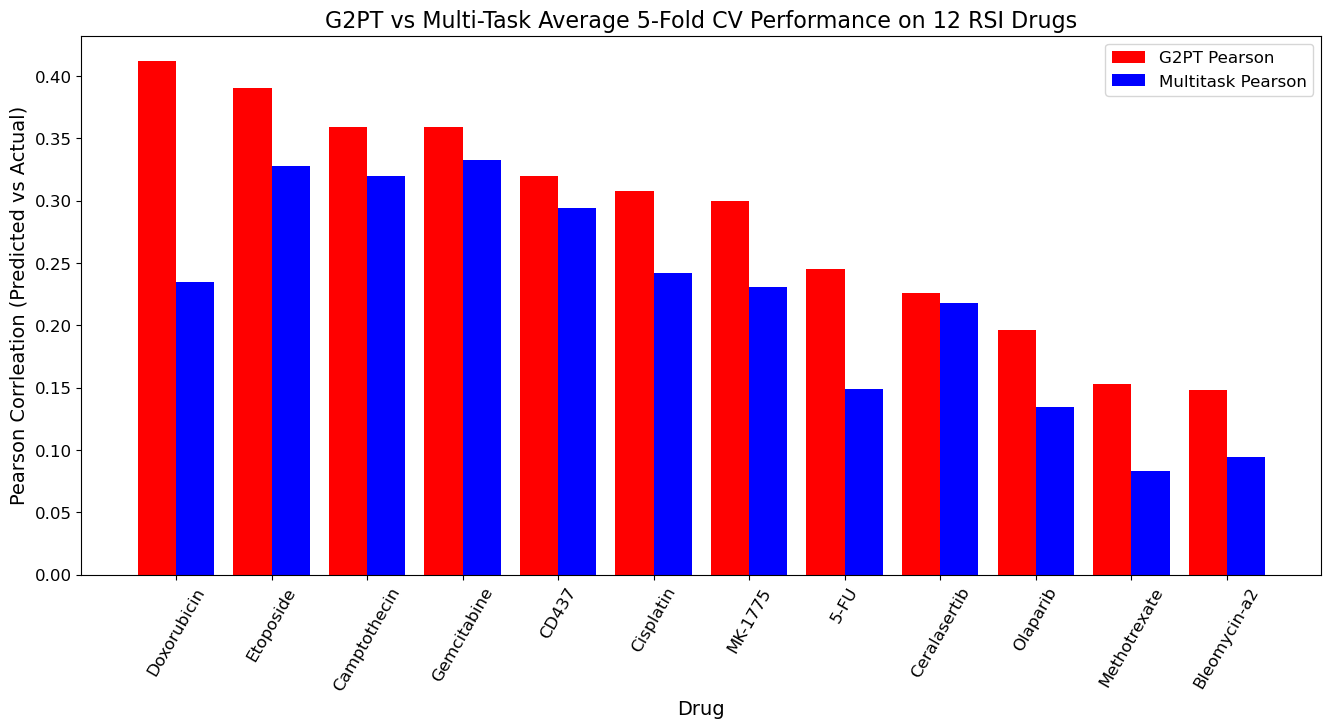

In [61]:
drugs = list(set(list(smiles_to_name.values())))
g2pt, multitask = [], []
ttest_pearson = {}
for drug in drugs:
    g2pt_drug_result = []
    multitask_drug_result = []
    for i in range(5):
        g2pt_drug_result.append(g2pt_pearson[i][drug])
        multitask_drug_result.append(multitask_pearson[i][drug])
    g2pt.append(np.mean(g2pt_drug_result))
    multitask.append(np.mean(multitask_drug_result))
    ttest_pearson[drug] = ttest_ind(g2pt_drug_result, multitask_drug_result, alternative = "greater")

g2pt_sorted_indices = np.argsort(g2pt)[::-1][:len(g2pt)]
g2pt = [g2pt[i] for i in g2pt_sorted_indices]
multitask = [multitask[i] for i in g2pt_sorted_indices]
drugs = [drugs[i] for i in g2pt_sorted_indices]

X_axis = np.arange(len(drugs)) 
  
plt.bar(X_axis - 0.2, g2pt, 0.4, label = 'G2PT Pearson', color = "red") 
plt.bar(X_axis + 0.2, multitask, 0.4, label = 'Multitask Pearson', color = "blue") 

plt.rcParams["figure.figsize"] = [16, 7]
plt.xticks(X_axis, drugs, fontsize = 12) 
plt.xlabel("Drug", fontsize = 14) 
plt.ylabel("Pearson Corrleation (Predicted vs Actual)", fontsize = 14) 
plt.xticks(rotation=60)
plt.yticks(fontsize = 12)
plt.title('G2PT vs Multi-Task Average 5-Fold CV Performance on 12 RSI Drugs', fontsize = 16)
plt.legend(fontsize = 12)
plt.show()

In [62]:
ttest_pearson

{'Doxorubicin': Ttest_indResult(statistic=4.885179485875302, pvalue=0.0006081778521432811),
 'Ceralasertib': Ttest_indResult(statistic=0.2279212885073291, pvalue=0.41271243216034487),
 'Etoposide': Ttest_indResult(statistic=1.7360841051242113, pvalue=0.060380411322089635),
 '5-FU': Ttest_indResult(statistic=2.596645583379228, pvalue=0.015891540331150596),
 'Olaparib': Ttest_indResult(statistic=1.7295696787603392, pvalue=0.06098076983857278),
 'Cisplatin': Ttest_indResult(statistic=1.4688213631756755, pvalue=0.0900361485132253),
 'Bleomycin-a2': Ttest_indResult(statistic=0.8750304947031224, pvalue=0.20352990546576583),
 'MK-1775': Ttest_indResult(statistic=2.60692321198234, pvalue=0.015639738773872622),
 'Gemcitabine': Ttest_indResult(statistic=0.6846322226980759, pvalue=0.25645921873462507),
 'CD437': Ttest_indResult(statistic=0.62828251120068, pvalue=0.273666082813678),
 'Camptothecin': Ttest_indResult(statistic=1.0484603301621083, pvalue=0.1625330155217459),
 'Methotrexate': Ttest_in

### Compare G2PT to Multi-Task with Odds Ratio

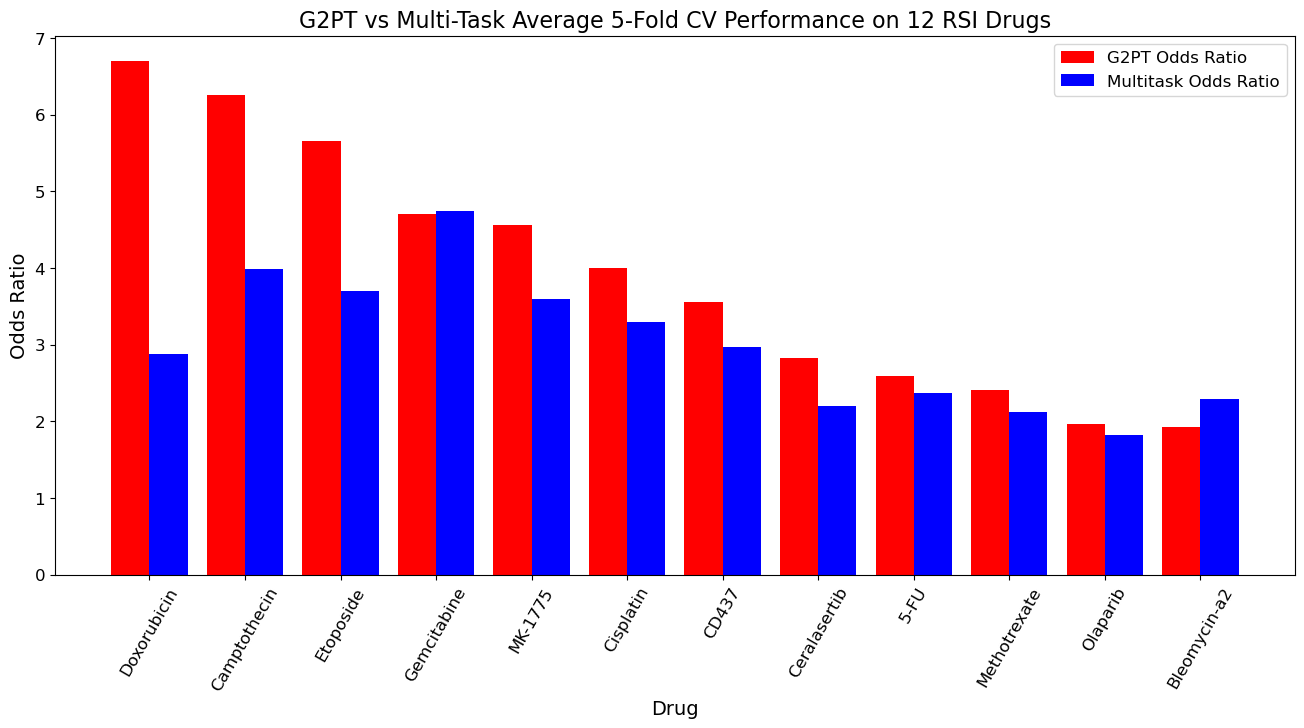

In [63]:
drugs = list(set(list(smiles_to_name.values())))
g2pt, multitask = [], []
ttest_odds = {}
for drug in drugs:
    g2pt_drug_result = []
    multitask_drug_result = []
    for i in range(5):
        g2pt_drug_result.append(g2pt_odds[i][drug])
        multitask_drug_result.append(multitask_odds[i][drug])
    g2pt.append(np.mean(g2pt_drug_result))
    multitask.append(np.mean(multitask_drug_result))
    ttest_odds[drug] = ttest_ind(g2pt_drug_result, multitask_drug_result, alternative = "greater")

g2pt_sorted_indices = np.argsort(g2pt)[::-1][:len(g2pt)]
g2pt = [g2pt[i] for i in g2pt_sorted_indices]
multitask = [multitask[i] for i in g2pt_sorted_indices]
drugs = [drugs[i] for i in g2pt_sorted_indices]

X_axis = np.arange(len(drugs)) 
  
plt.bar(X_axis - 0.2, g2pt, 0.4, label = 'G2PT Odds Ratio', color = "red") 
plt.bar(X_axis + 0.2, multitask, 0.4, label = 'Multitask Odds Ratio', color = "blue") 

plt.rcParams["figure.figsize"] = [16, 7]
plt.xticks(X_axis, drugs, fontsize = 12) 
plt.xlabel("Drug", fontsize = 14) 
plt.ylabel("Odds Ratio", fontsize = 14) 
plt.xticks(rotation=60)
plt.yticks(fontsize = 12)
plt.title('G2PT vs Multi-Task Average 5-Fold CV Performance on 12 RSI Drugs', fontsize = 16)
plt.legend(fontsize = 12)
plt.show()

In [64]:
ttest_odds

{'Doxorubicin': Ttest_indResult(statistic=2.8299098473912614, pvalue=0.011076642436324958),
 'Ceralasertib': Ttest_indResult(statistic=1.4390305145900777, pvalue=0.09404708126742535),
 'Etoposide': Ttest_indResult(statistic=1.689301208584928, pvalue=0.06481695895822093),
 '5-FU': Ttest_indResult(statistic=0.2988593220001887, pvalue=0.3863317633812039),
 'Olaparib': Ttest_indResult(statistic=0.4714464655545501, pvalue=0.3249557367169483),
 'Cisplatin': Ttest_indResult(statistic=0.5287411286114624, pvalue=0.305667878651759),
 'Bleomycin-a2': Ttest_indResult(statistic=-0.43091226391268383, pvalue=0.6610463068674697),
 'MK-1775': Ttest_indResult(statistic=0.6244388133132984, pvalue=0.27486435691566274),
 'Gemcitabine': Ttest_indResult(statistic=-0.04841055876510521, pvalue=0.5187120935408255),
 'CD437': Ttest_indResult(statistic=0.7930501729395443, pvalue=0.22531298475973194),
 'Camptothecin': Ttest_indResult(statistic=1.5325805089298832, pvalue=0.08195908374231108),
 'Methotrexate': Ttest

## NEW CODE: Redo the Performance Plot for Odds Ratio and Pearson

In [65]:
def multitask_odds_ratio(task_list, test, predictions):

    multitask_dir = '/cellar/users/zwallace/multitask_vnn'
    drugs = []
    with open(multitask_dir+task_list, "r") as file:
        for line in file:
            drugs.append(line.strip())

    odds = []
    for i in range(5):
        true = pd.read_csv(multitask_dir+test+str(i)+".txt",
                           sep = '\t',
                           index_col=[0])
        predict = pd.read_csv(multitask_dir+predictions+str(i)+"/predict.txt",
                              sep = ' ',
                              header = None)
        drug_odds = {}
        for j in range(len(drugs)):
            name = smiles_to_name[drugs[j]]
            drug_odds[name] = odds_ratio(np.asarray(list(true[true.columns[j]])), np.asarray(list(predict[j])))
        odds.append(drug_odds)

    return(odds)

In [66]:
multitask_odds1 = multitask_odds_ratio("/sample/task_list_main.txt", "/sample/test_data_main_", "/model_main_old_")
multitask_odds2 = multitask_odds_ratio("/sample/task_list_extra.txt", "/sample/test_data_extra_", "/model_extra_old_")

In [67]:
multitask_odds = []
for i in range(5):
    odds = {}
    for drug in multitask_odds1[i].keys():
        odds[drug] = multitask_odds1[i][drug]
    for drug in multitask_odds2[i].keys():
        odds[drug] = multitask_odds2[i][drug]
    multitask_odds.append(odds)

### Create Side-by-Side Error Bar Plots for Odds Ratio

In [69]:
from scipy.stats import sem

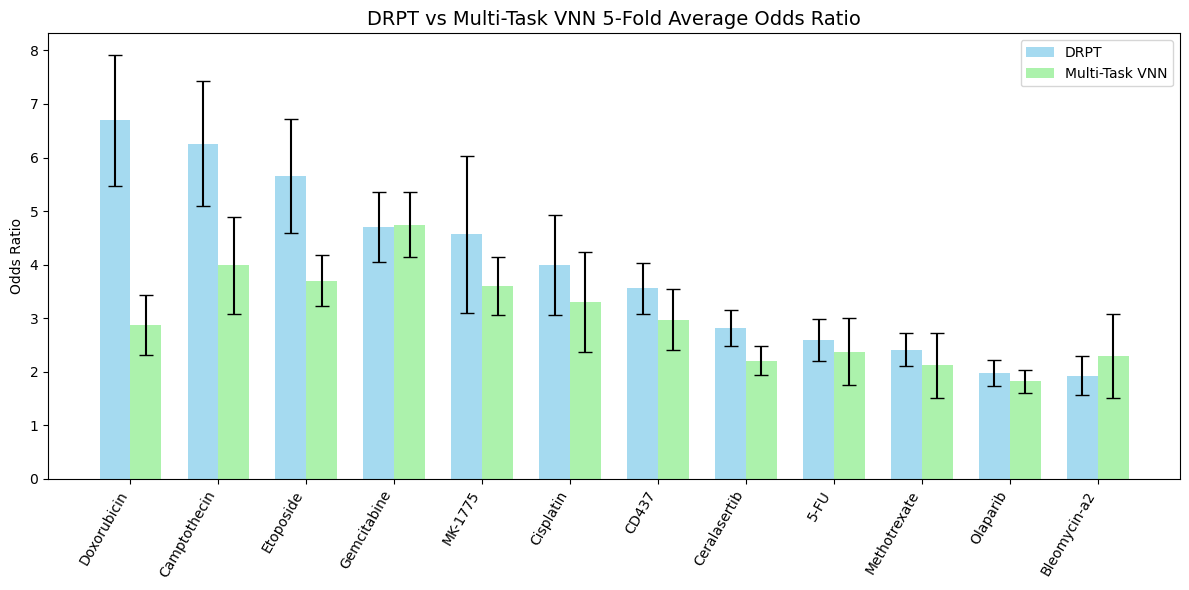

In [70]:
A = g2pt_odds
B = multitask_odds

# Convert the lists of dictionaries into DataFrames
df_A = pd.DataFrame(A)
df_B = pd.DataFrame(B)

# Calculate the mean and standard error of the mean for each drug
mean_values_A = df_A.mean()
error_values_A = pd.Series(sem(df_A, axis=0), index=df_A.columns)

mean_values_B = df_B.mean()
error_values_B = pd.Series(sem(df_B, axis=0), index=df_B.columns)

# Sort the drugs by their average odds ratio values in A in descending order
sorted_indices = mean_values_A.sort_values(ascending=False).index
mean_values_A = mean_values_A.loc[sorted_indices]
error_values_A = error_values_A.loc[sorted_indices]

mean_values_B = mean_values_B.loc[sorted_indices]
error_values_B = error_values_B.loc[sorted_indices]

# Plotting
x = np.arange(len(mean_values_A))  # the label locations
width = 0.35  # the width of the bars

fig, ax = plt.subplots(figsize=(12, 6))

# Bar plot for A
rects1 = ax.bar(x - width/2, mean_values_A, width, yerr=error_values_A, capsize=5, label='DRPT', alpha=0.75, color='skyblue')

# Bar plot for B
rects2 = ax.bar(x + width/2, mean_values_B, width, yerr=error_values_B, capsize=5, label='Multi-Task VNN', alpha=0.75, color='lightgreen')

# Add labels, title, and legend
ax.set_ylabel('Odds Ratio')
ax.set_title('DRPT vs Multi-Task VNN 5-Fold Average Odds Ratio', fontsize = 14)
ax.set_xticks(x)
ax.set_xticklabels(mean_values_A.index, rotation=60, ha='right')
ax.legend()

fig.tight_layout()

plt.show()

### Side-by-side Error Plot for Pearson Corr.

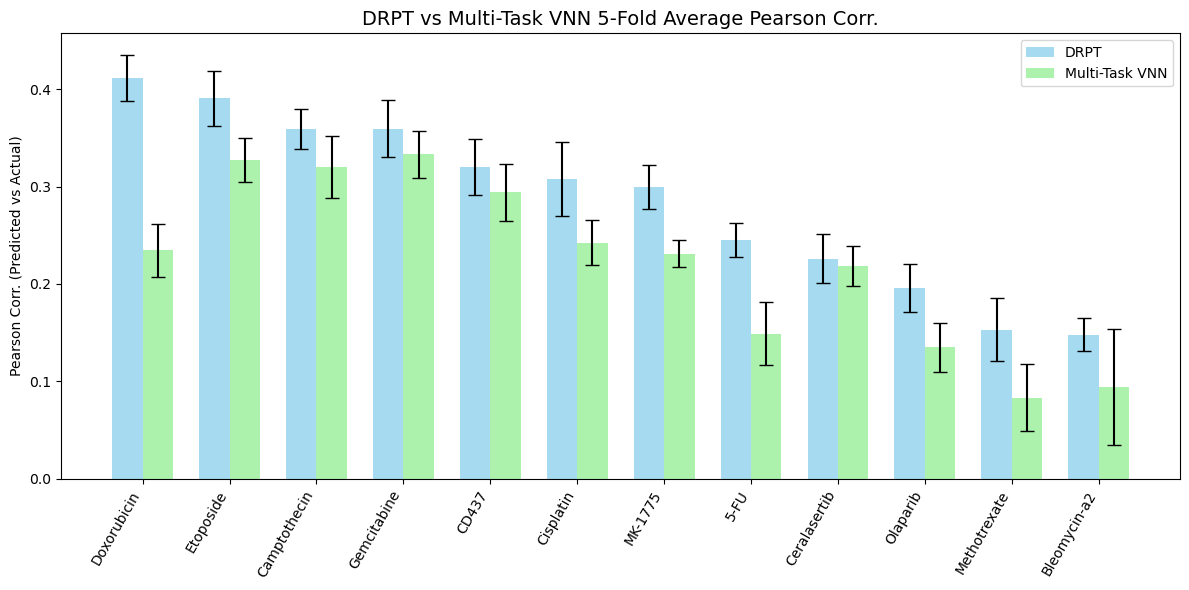

In [73]:
multi_pearson = []
for key in multitask_pearson.keys():
    multi_pearson.append(multitask_pearson[key])

A = g2pt_pearson
B = multi_pearson

# Convert the lists of dictionaries into DataFrames
df_A = pd.DataFrame(A)
df_B = pd.DataFrame(B)

# Calculate the mean and standard error of the mean for each drug
mean_values_A = df_A.mean()
error_values_A = pd.Series(sem(df_A, axis=0), index=df_A.columns)

mean_values_B = df_B.mean()
error_values_B = pd.Series(sem(df_B, axis=0), index=df_B.columns)

# Sort the drugs by their average odds ratio values in A in descending order
sorted_indices = mean_values_A.sort_values(ascending=False).index
mean_values_A = mean_values_A.loc[sorted_indices]
error_values_A = error_values_A.loc[sorted_indices]

mean_values_B = mean_values_B.loc[sorted_indices]
error_values_B = error_values_B.loc[sorted_indices]

# Plotting
x = np.arange(len(mean_values_A))  # the label locations
width = 0.35  # the width of the bars

fig, ax = plt.subplots(figsize=(12, 6))

# Bar plot for A
rects1 = ax.bar(x - width/2, mean_values_A, width, yerr=error_values_A, capsize=5, label='DRPT', alpha=0.75, color='skyblue')

# Bar plot for B
rects2 = ax.bar(x + width/2, mean_values_B, width, yerr=error_values_B, capsize=5, label='Multi-Task VNN', alpha=0.75, color='lightgreen')

# Add labels, title, and legend
ax.set_ylabel('Pearson Corr. (Predicted vs Actual)')
ax.set_title('DRPT vs Multi-Task VNN 5-Fold Average Pearson Corr.', fontsize = 14)
ax.set_xticks(x)
ax.set_xticklabels(mean_values_A.index, rotation=60, ha='right')
ax.legend()

fig.tight_layout()

plt.show()

## Compare Diff Transformer G2PT to Normal G2PT

### Get grid4 results

In [25]:
g2pt_pearson_nodiff = {0:{}, 1:{}, 2:{}, 3:{}, 4:{}}
g2pt_odds_nodiff = {0:{}, 1:{}, 2:{}, 3:{}, 4:{}}
for i in range(5):
    train = 'data/train_dataset_rsi_'+str(i)+'.txt'
    test = 'data/test_dataset_rsi_'+str(i)+'.txt'
    model = 'models_oldcn/rsi_model_'+str(i)+'.pt'
    model_i = instantiate_model(train, model, diff_transformer = False)
    performance_i_pearson = evaluate_model(train, test, model_i, sys2cell=True, cell2sys=True, sys2gene=False, gene2drug=False, 
                                           mut2gene=True, with_indices=True, method="pearson", new_copynumber = False)
    performance_i_odds = evaluate_model(train, test, model_i, sys2cell=True, cell2sys=True, sys2gene=False, gene2drug=False, 
                                        mut2gene=True, with_indices=True, method="odds ratio", new_copynumber = False)
    g2pt_pearson_nodiff[i] = performance_i_pearson
    g2pt_odds_nodiff[i] = performance_i_odds

### Compare New Model to Old Model: Pearson

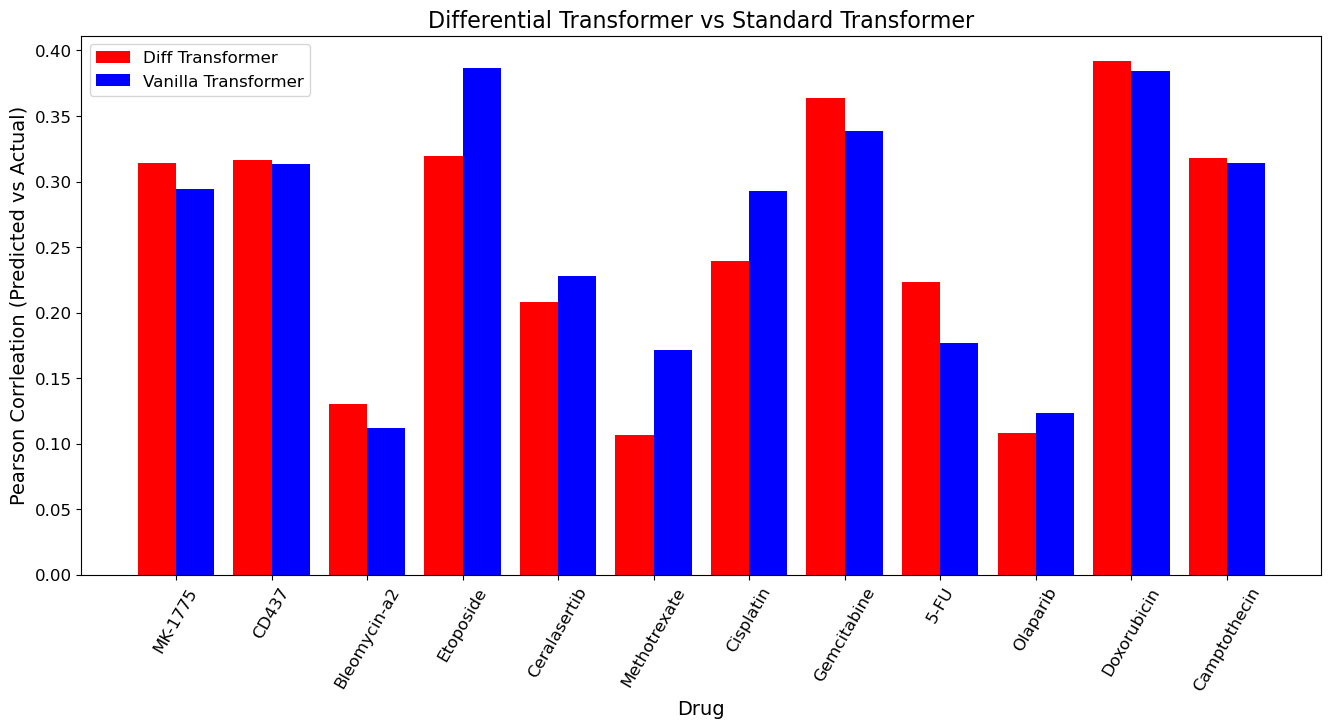

In [26]:
drugs = list(set(list(smiles_to_name.values())))
diff, nodiff = [], []
for drug in drugs:
    diff_result = []
    nodiff_result = []
    for i in range(5):
        diff_result.append(g2pt_pearson[i][drug])
        nodiff_result.append(g2pt_pearson_nodiff[i][drug])
    diff.append(np.mean(diff_result))
    nodiff.append(np.mean(nodiff_result))

X_axis = np.arange(len(drugs)) 
  
plt.bar(X_axis - 0.2, diff, 0.4, label = 'Diff Transformer', color = "red") 
plt.bar(X_axis + 0.2, nodiff, 0.4, label = 'Vanilla Transformer', color = "blue") 

plt.rcParams["figure.figsize"] = [16, 7]
plt.xticks(X_axis, drugs, fontsize = 12) 
plt.xlabel("Drug", fontsize = 14) 
plt.ylabel("Pearson Corrleation (Predicted vs Actual)", fontsize = 14) 
plt.xticks(rotation=60)
plt.yticks(fontsize = 12)
plt.title('Differential Transformer vs Standard Transformer', fontsize = 16)
plt.legend(fontsize = 12)
plt.show()

### Compare New Model to Old: Odds Ratio

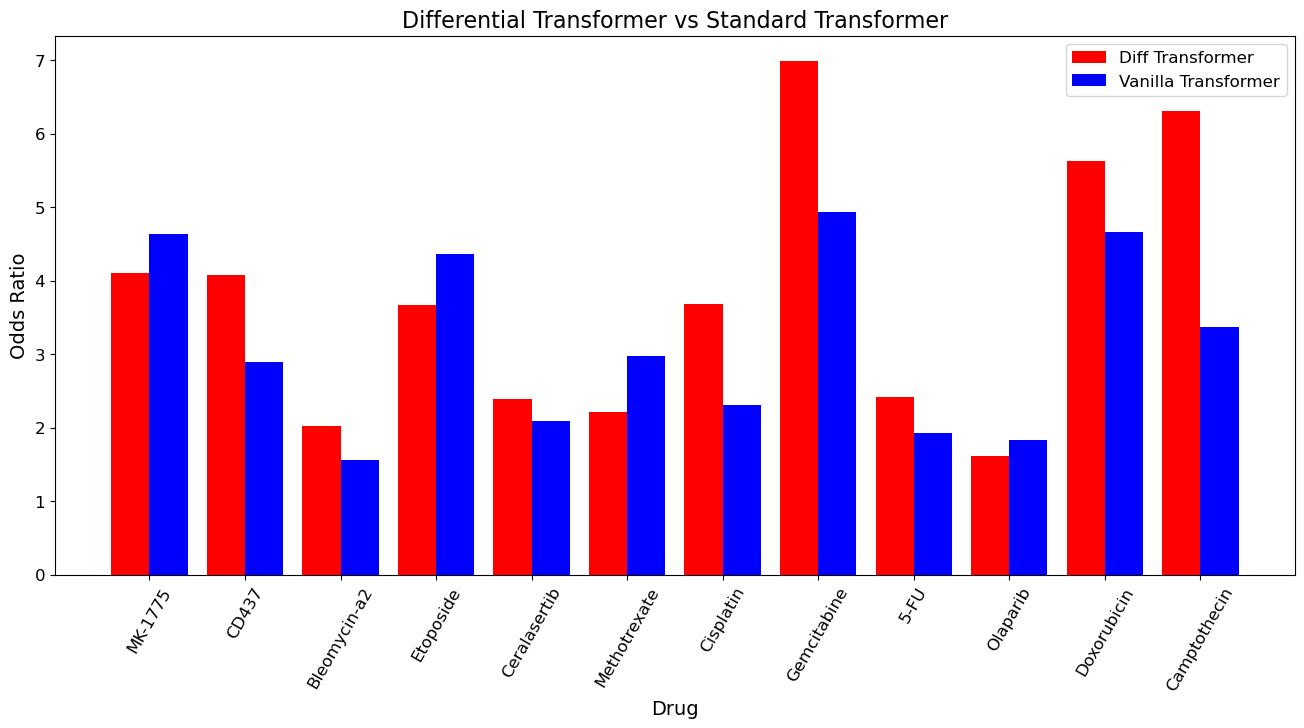

In [27]:
drugs = list(set(list(smiles_to_name.values())))
diff, nodiff = [], []
for drug in drugs:
    diff_result = []
    nodiff_result = []
    for i in range(5):
        diff_result.append(g2pt_odds[i][drug])
        nodiff_result.append(g2pt_odds_nodiff[i][drug])
    diff.append(np.mean(diff_result))
    nodiff.append(np.mean(nodiff_result))

X_axis = np.arange(len(drugs)) 
  
plt.bar(X_axis - 0.2, diff, 0.4, label = 'Diff Transformer', color = "red") 
plt.bar(X_axis + 0.2, nodiff, 0.4, label = 'Vanilla Transformer', color = "blue") 

plt.rcParams["figure.figsize"] = [16, 7]
plt.xticks(X_axis, drugs, fontsize = 12) 
plt.xlabel("Drug", fontsize = 14) 
plt.ylabel("Odds Ratio", fontsize = 14) 
plt.xticks(rotation=60)
plt.yticks(fontsize = 12)
plt.title('Differential Transformer vs Standard Transformer', fontsize = 16)
plt.legend(fontsize = 12)
plt.show()

## Compare models_oldcn to grid_4

In [28]:
g2pt_pearson_grid4 = {0:{}, 1:{}, 2:{}, 3:{}, 4:{}}
g2pt_odds_grid4 = {0:{}, 1:{}, 2:{}, 3:{}, 4:{}}
for i in range(5):
    train = 'data/train_dataset_rsi_'+str(i)+'.txt'
    test = 'data/test_dataset_rsi_'+str(i)+'.txt'
    model = 'grid_4/rsi_model_'+str(i)+'.pt'
    model_i = instantiate_model(train, model, diff_transformer = False)
    performance_i_pearson = evaluate_model(train, test, model_i, sys2cell=True, cell2sys=True, sys2gene=False, gene2drug=False, 
                                           mut2gene=True, with_indices=True, method="pearson", new_copynumber = False)
    performance_i_odds = evaluate_model(train, test, model_i, sys2cell=True, cell2sys=True, sys2gene=False, gene2drug=False, 
                                        mut2gene=True, with_indices=True, method="odds ratio", new_copynumber = False)
    g2pt_pearson_grid4[i] = performance_i_pearson
    g2pt_odds_grid4[i] = performance_i_odds

In [29]:
g2pt_pearson_oldcn = {0:{}, 1:{}, 2:{}, 3:{}, 4:{}}
g2pt_odds_oldcn = {0:{}, 1:{}, 2:{}, 3:{}, 4:{}}
for i in range(5):
    train = 'data/train_dataset_rsi_'+str(i)+'.txt'
    test = 'data/test_dataset_rsi_'+str(i)+'.txt'
    model = 'models_oldcn/rsi_model_'+str(i)+'.pt'
    model_i = instantiate_model(train, model, diff_transformer = False)
    performance_i_pearson = evaluate_model(train, test, model_i, sys2cell=True, cell2sys=True, sys2gene=False, gene2drug=False, 
                                           mut2gene=True, with_indices=True, method="pearson", new_copynumber = False)
    performance_i_odds = evaluate_model(train, test, model_i, sys2cell=True, cell2sys=True, sys2gene=False, gene2drug=False, 
                                        mut2gene=True, with_indices=True, method="odds ratio", new_copynumber = False)
    g2pt_pearson_oldcn[i] = performance_i_pearson
    g2pt_odds_oldcn[i] = performance_i_odds

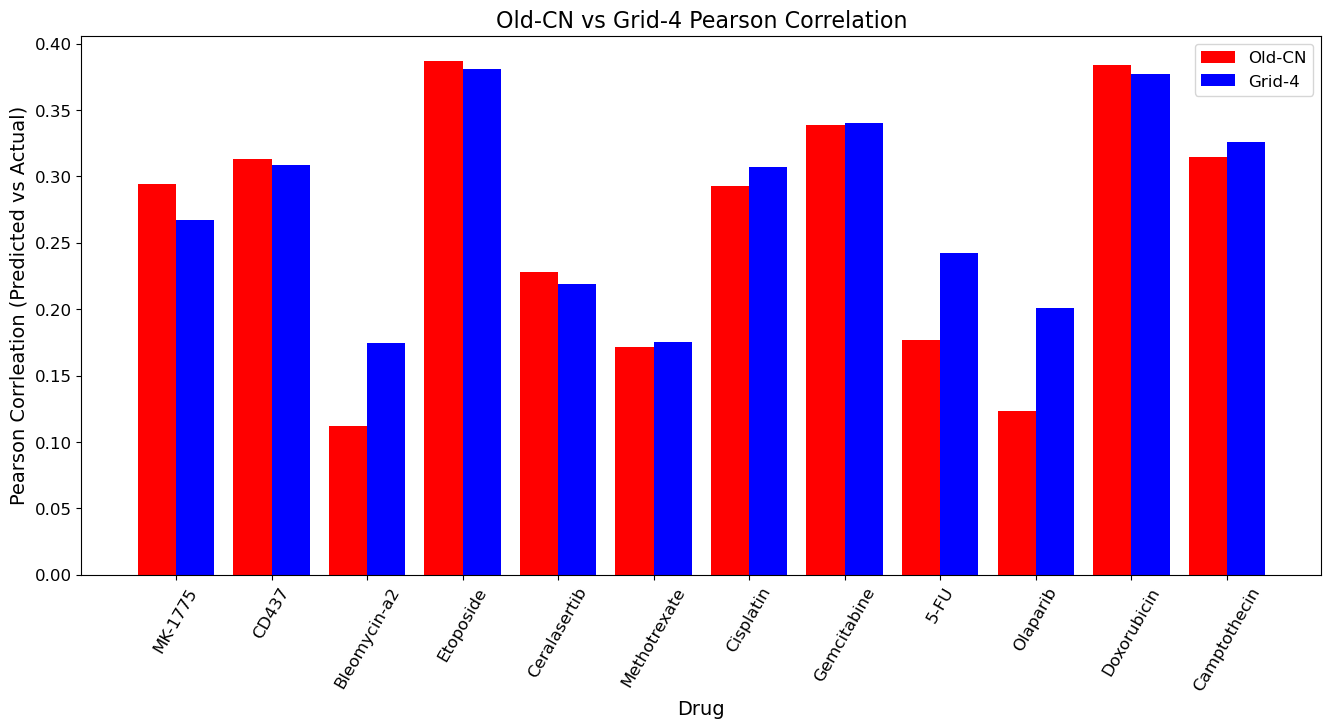

In [30]:
drugs = list(set(list(smiles_to_name.values())))
oldcn, grid4 = [], []
for drug in drugs:
    oldcn_result = []
    grid4_result = []
    for i in range(5):
        oldcn_result.append(g2pt_pearson_oldcn[i][drug])
        grid4_result.append(g2pt_pearson_grid4[i][drug])
    oldcn.append(np.mean(oldcn_result))
    grid4.append(np.mean(grid4_result))

X_axis = np.arange(len(drugs)) 
  
plt.bar(X_axis - 0.2, oldcn, 0.4, label = 'Old-CN', color = "red") 
plt.bar(X_axis + 0.2, grid4, 0.4, label = 'Grid-4', color = "blue") 

plt.rcParams["figure.figsize"] = [16, 7]
plt.xticks(X_axis, drugs, fontsize = 12) 
plt.xlabel("Drug", fontsize = 14) 
plt.ylabel("Pearson Corrleation (Predicted vs Actual)", fontsize = 14) 
plt.xticks(rotation=60)
plt.yticks(fontsize = 12)
plt.title('Old-CN vs Grid-4 Pearson Correlation', fontsize = 16)
plt.legend(fontsize = 12)
plt.show()